In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
print(sys.path)
sys.path.append('/home/lankenau/isotools/src')

['/home/lankenau/miniforge-pypy3/envs/isodev/lib/python312.zip', '/home/lankenau/miniforge-pypy3/envs/isodev/lib/python3.12', '/home/lankenau/miniforge-pypy3/envs/isodev/lib/python3.12/lib-dynload', '', '/home/lankenau/miniforge-pypy3/envs/isodev/lib/python3.12/site-packages']


In [3]:
from isotools import Transcriptome, Gene, SegmentGraph
import matplotlib.pyplot as plt
from intervaltree import IntervalTree  # , Interval

In [4]:
import logging
# set up logging
logger=logging.getLogger('isotools')
logger.setLevel(logging.DEBUG)

In [5]:
path='demonstration_dataset'
isoseq=Transcriptome.load(f'{path}/PacBio_isotools.pkl')

In [6]:
import random
# Hard coding types because python is too stupid or too smart for me
# Exploring the data
interval_tree: IntervalTree[Gene] = isoseq.data['chr8']
# Get a random gene from the list of genes
gene: Gene = random.choice(list(interval_tree))

# Interesting genes
gene: Gene = isoseq['ENSG00000104490.18']
# GPAT4-AS1
gene: Gene = isoseq['GPAT4-AS1']
gpat4: Gene = isoseq['GPAT4-AS1']
# RPL23AP53
# gene: Gene = isoseq['RPL23AP53']
# GOLGA7
# gene: Gene = isoseq['GOLGA7']
golga: Gene = isoseq['GOLGA7']

# Print the gene information
print(gene.begin)
print(gene.end)
print(gene.chrom)
print(gene.id)
print(gene.name)
print(gene.strand)
print(gene.transcripts)
print(gene.coverage, '\n')
seg_graph: SegmentGraph = gene.segment_graph
print(seg_graph.get_node_matrix())
print([bubble for bubble in seg_graph.find_splice_bubbles()])
print(seg_graph.strand)
print(seg_graph._graph)

41509592
41578421
chr8
ENSG00000253133.2
GPAT4-AS1
-
[{'exons': [[41490589, 41490617], [41490832, 41490965], [41497506, 41497661], [41505910, 41506012], [41507058, 41507119], [41509581, 41509875]], 'strand': '-', 'coverage': {'GM12878_b': 1}, 'TSS': {'GM12878_b': {41509875: 1}}, 'PAS': {'GM12878_b': {41490589: 1}}, 'annotation': (3, {'novel intronic PAS': [[41490589, 41490617]], 'novel exon': [[41490832, 41490965], [41497506, 41497661], [41505910, 41506012], [41507058, 41507119]], "novel 5' splice site": [(41509581, 11)], "5' fragment": [[41509875, 41578421]]}), 'novel_splice_sites': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'TSS_unified': {'GM12878_b': {41509875: 1}}, 'PAS_unified': {'GM12878_b': {41490589: 1}}, 'direct_repeat_len': [3, 3, 6, 4, 8], 'noncanonical_splicing': [(0, 'CTAC'), (1, 'GTAC'), (2, 'CTAC'), (3, 'CTAC'), (4, 'GTCT')], 'downstream_A_content': 0.1}, {'exons': [[41532763, 41534078]], 'strand': '-', 'coverage': {'K562_b': 1}, 'TSS': {'K562_b': {41534078: 1}}, 'PAS': {'K562_b':

In [7]:
gene.data

{'ID': 'ENSG00000253133.2',
 'chr': 'chr8',
 'strand': '-',
 'name': 'GPAT4-AS1',
 'reference': {'gene_type': 'lncRNA',
  'level': '1',
  'hgnc_id': 'HGNC:55539',
  'tag': 'overlapping_locus',
  'havana_gene': 'OTTHUMG00000164080.3',
  'transcripts': [{'transcript_id': 'ENST00000523081.2',
    'transcript_type': 'lncRNA',
    'transcript_name': 'GPAT4-AS1-201',
    'transcript_support_level': '2',
    'exons': [(41509592, 41512545),
     (41533686, 41534410),
     (41537070, 41537310),
     (41578305, 41578421)],
    'downstream_A_content': 0.36666666666666664,
    'ORF': (np.int64(41533985),
     np.int64(41534405),
     {"5'UTR": 361,
      'CDS': 420,
      "3'UTR": np.int64(3252),
      'start_codon': 'ATG',
      'stop_codon': 'TGA',
      'NMD': np.True_,
      'uORFs': 5,
      'ref_ids': None,
      'kozak': np.float64(-6.552160030630336),
      'fickett': 0.4822})}],
  'segment_graph': <isotools.splice_graph.SegmentGraph at 0x7f6db85c4f20>},
 'transcripts': [{'exons': [[414905

In [8]:
gene.ref_transcripts

[{'transcript_id': 'ENST00000523081.2',
  'transcript_type': 'lncRNA',
  'transcript_name': 'GPAT4-AS1-201',
  'transcript_support_level': '2',
  'exons': [(41509592, 41512545),
   (41533686, 41534410),
   (41537070, 41537310),
   (41578305, 41578421)],
  'downstream_A_content': 0.36666666666666664,
  'ORF': (np.int64(41533985),
   np.int64(41534405),
   {"5'UTR": 361,
    'CDS': 420,
    "3'UTR": np.int64(3252),
    'start_codon': 'ATG',
    'stop_codon': 'TGA',
    'NMD': np.True_,
    'uORFs': 5,
    'ref_ids': None,
    'kozak': np.float64(-6.552160030630336),
    'fickett': 0.4822})}]

In [9]:
print(isoseq['GPAT4-AS1'].n_ref_transcripts)
print(isoseq['GPAT4-AS1'].n_transcripts)

1
4


In [10]:
gene.transcripts[0]

{'exons': [[41490589, 41490617],
  [41490832, 41490965],
  [41497506, 41497661],
  [41505910, 41506012],
  [41507058, 41507119],
  [41509581, 41509875]],
 'strand': '-',
 'coverage': {'GM12878_b': 1},
 'TSS': {'GM12878_b': {41509875: 1}},
 'PAS': {'GM12878_b': {41490589: 1}},
 'annotation': (3,
  {'novel intronic PAS': [[41490589, 41490617]],
   'novel exon': [[41490832, 41490965],
    [41497506, 41497661],
    [41505910, 41506012],
    [41507058, 41507119]],
   "novel 5' splice site": [(41509581, 11)],
   "5' fragment": [[41509875, 41578421]]}),
 'novel_splice_sites': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'TSS_unified': {'GM12878_b': {41509875: 1}},
 'PAS_unified': {'GM12878_b': {41490589: 1}},
 'direct_repeat_len': [3, 3, 6, 4, 8],
 'noncanonical_splicing': [(0, 'CTAC'),
  (1, 'GTAC'),
  (2, 'CTAC'),
  (3, 'CTAC'),
  (4, 'GTCT')],
 'downstream_A_content': 0.1}

In [11]:
[bubble for bubble in seg_graph.find_splice_bubbles()]

[([1, 2, 3], [0], 0, 0, 'PAS'),
 ([3], [2], 10, 10, 'PAS'),
 ([2], [3], 7, 8, 'PAS'),
 ([0, 1], [2, 3], 11, 11, 'TSS')]

In [12]:
seg_graph.strand

'-'

In [13]:
for i, node in enumerate(seg_graph):
    print(i, node)

0 (41490589, 41490617, {}, {0: 1})
1 (41490832, 41490965, {0: 0}, {0: 2})
2 (41497506, 41497661, {0: 1}, {0: 3})
3 (41505910, 41506012, {0: 2}, {0: 4})
4 (41507058, 41507119, {0: 3}, {0: 5})
5 (41509581, 41509875, {0: 4}, {})
6 (41532763, 41533764, {}, {1: 7})
7 (41533764, 41534078, {1: 6}, {3: 8})
8 (41534078, 41534410, {3: 7}, {3: 9})
9 (41537070, 41537310, {3: 8}, {3: 11})
10 (41574320, 41574399, {}, {2: 11})
11 (41578305, 41578393, {2: 10, 3: 9}, {})


In [14]:
for i, node in enumerate(isoseq['GOLGA7'].segment_graph):
    print(i, node)

0 (41490439, 41490466, {}, {27: 1})
1 (41490466, 41490484, {27: 0}, {19: 2, 27: 2})
2 (41490484, 41490500, {19: 1, 27: 1}, {16: 3, 17: 3, 18: 3, 19: 13, 27: 3, 44: 3})
3 (41490500, 41490518, {16: 2, 17: 2, 18: 2, 27: 2, 44: 2}, {16: 4, 17: 4, 18: 4, 27: 13, 44: 4})
4 (41490518, 41490563, {16: 3, 17: 3, 18: 3, 44: 3}, {16: 5, 17: 5, 18: 5, 44: 5})
5 (41490563, 41490566, {16: 4, 17: 4, 18: 4, 44: 4}, {16: 13, 17: 13, 18: 13, 29: 6, 44: 18})
6 (41490566, np.int64(41490582), {29: 5}, {29: 7})
7 (np.int64(41490582), 41490613, {29: 6}, {0: 8, 1: 8, 2: 8, 3: 8, 4: 8, 5: 13, 6: 8, 20: 8, 21: 16, 22: 8, 23: 8, 28: 8, 29: 8, 30: 8, 31: 13, 32: 8, 33: 8, 34: 8, 36: 8, 37: 8, 38: 8, 41: 8, 45: 18, 46: 8, 47: 8, 48: 8})
8 (41490613, 41490614, {0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 6: 7, 20: 7, 22: 7, 23: 7, 28: 7, 29: 7, 30: 7, 32: 7, 33: 7, 34: 7, 36: 7, 37: 7, 38: 7, 41: 7, 46: 7, 47: 7, 48: 7}, {0: 9, 1: 9, 2: 9, 3: 9, 4: 9, 6: 9, 20: 9, 22: 9, 23: 9, 28: 9, 29: 13, 30: 9, 32: 9, 33: 9, 34: 9, 36: 9, 37

# GPAT4 vs GOLGA7

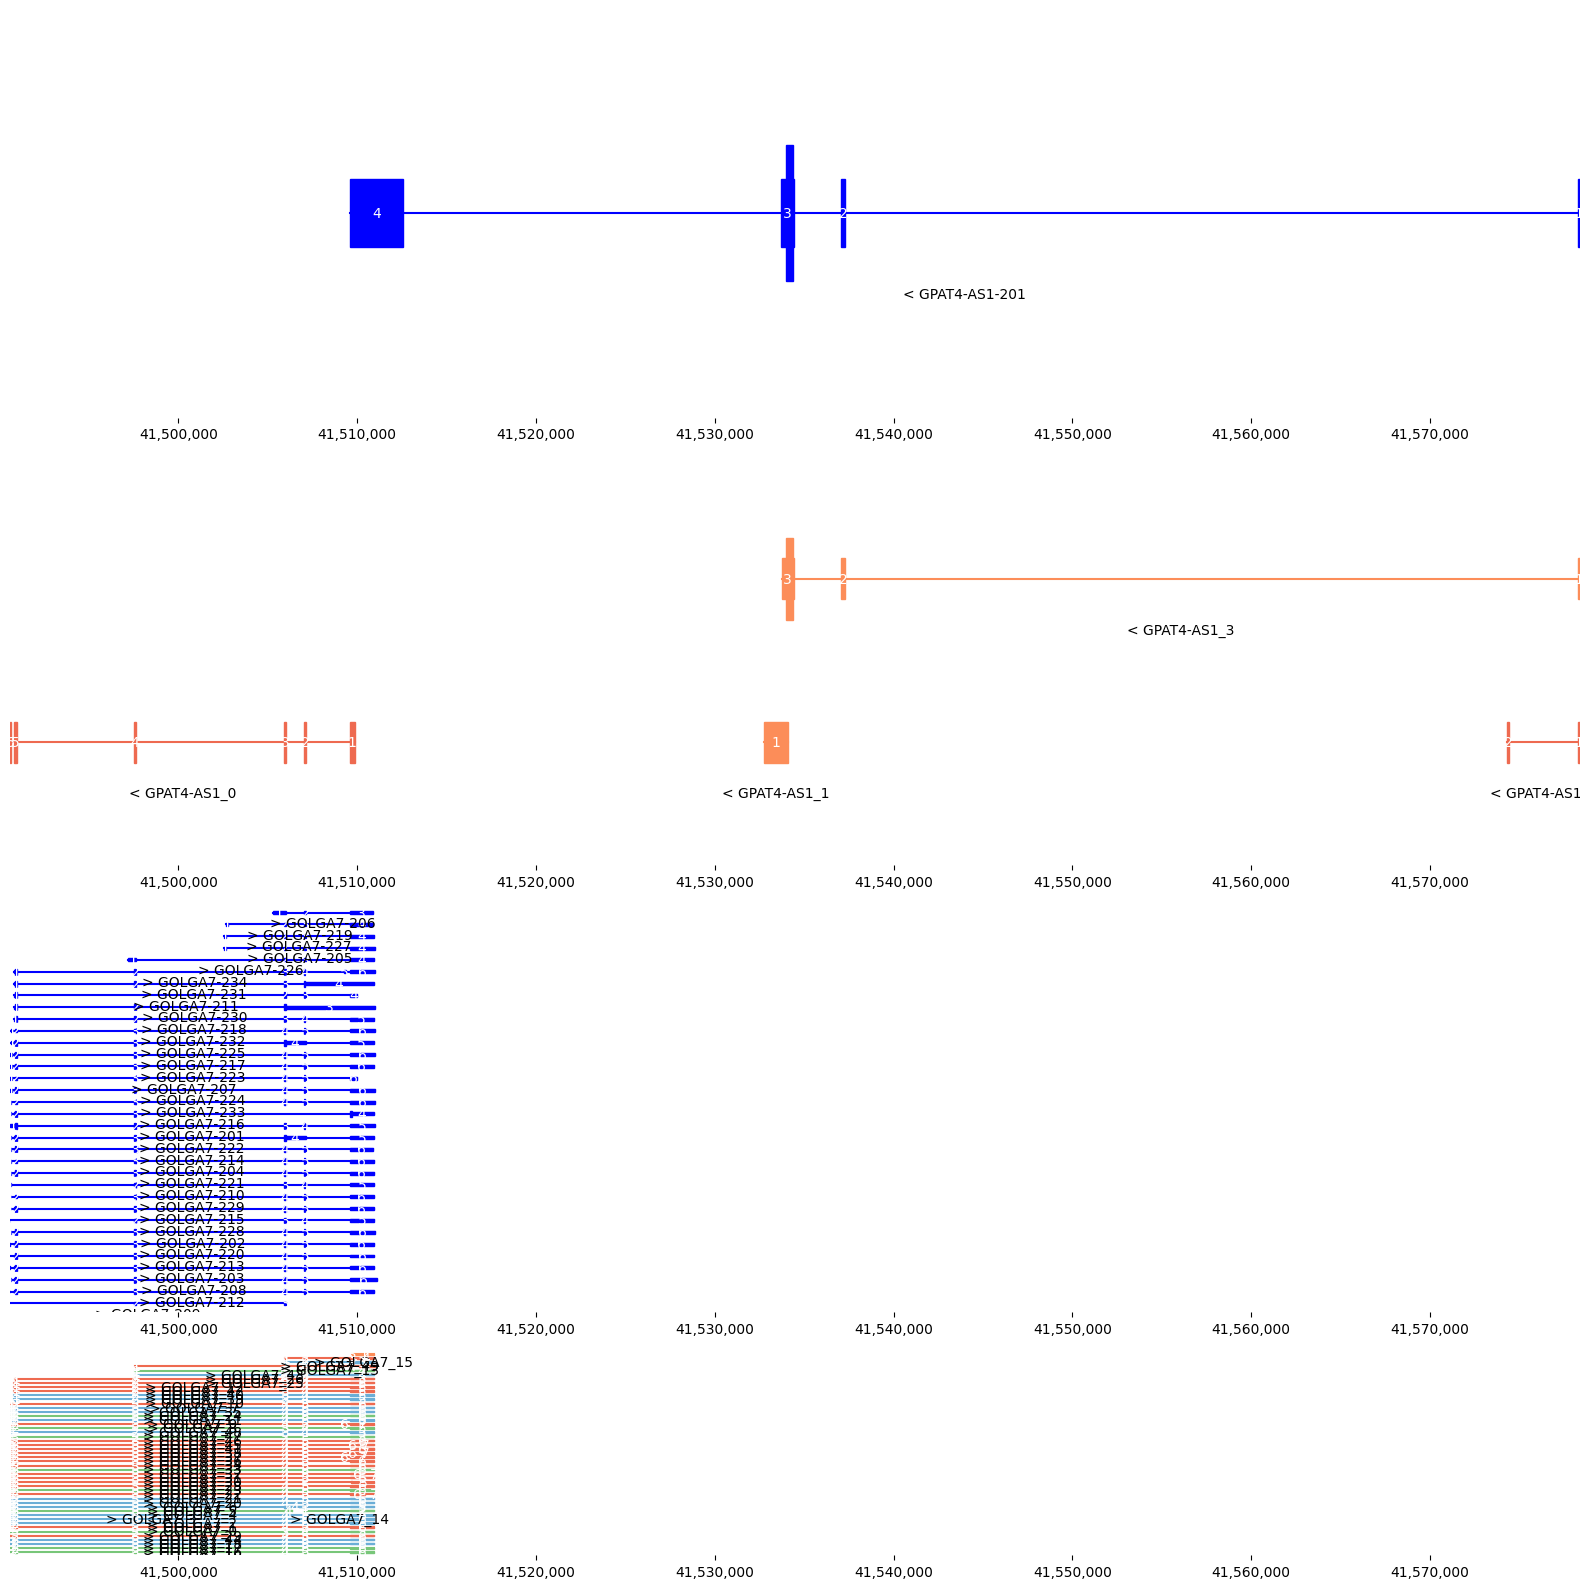

In [15]:
f,axs=plt.subplots(4, figsize=(16, 16), gridspec_kw={'height_ratios': [2, 2, 2, 1]})
isoseq['GPAT4-AS1'].gene_track(ax=axs[0], title='', x_range=(41490589,41578393))
isoseq['GPAT4-AS1'].gene_track(ax=axs[1], title='', reference=False, x_range=(41490589,41578393))
isoseq['GOLGA7'].gene_track(ax=axs[3], title='', reference=False, x_range=(41490589,41578393))
isoseq['GOLGA7'].gene_track(ax=axs[2], title='', x_range=(41490589,41578393))
f.tight_layout()

In [16]:
[exon[0] for transcript in gpat4.ref_transcripts for exon in transcript['exons'] ]

[41509592, 41533686, 41537070, 41578305]

In [17]:
sorted([exon[0] for transcript in golga.ref_transcripts for exon in transcript['exons']])

[41488199,
 41490291,
 41490305,
 41490395,
 41490426,
 41490447,
 41490449,
 41490455,
 41490545,
 41490558,
 41490561,
 41490561,
 41490567,
 41490578,
 41490578,
 41490581,
 41490585,
 41490592,
 41490606,
 41490611,
 41490615,
 41490615,
 41490648,
 41490657,
 41490791,
 41490822,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490832,
 41490869,
 41490869,
 41490869,
 41490869,
 41490869,
 41497213,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41497508,
 41502556,
 41502568,
 41502654,
 41505272,
 41505910,
 41505910,
 41505910,
 41505910,
 41505910,
 41505910,
 41505910,
 41505910,
 41505910,